In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer


data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Dataset Shape: {df.shape}")
print(f"Features: {df.shape[1] - 1}")
print(f"Samples: {df.shape[0]}")
print(f"\nTarget Distribution:\n{df['target'].value_counts()}")
df.head()


Dataset Shape: (569, 31)
Features: 30
Samples: 569

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


print(f"Missing Values:\n{df.isnull().sum().sum()}")


X = df.drop('target', axis=1)
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")


Missing Values:
0

Training set: (455, 30)
Test set: (114, 30)


/tmp/ipykernel_1166/4028667353.py:20: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[top_features].hist(ax=ax2, bins=20, color='#3498db', edgecolor='black', alpha=0.7)


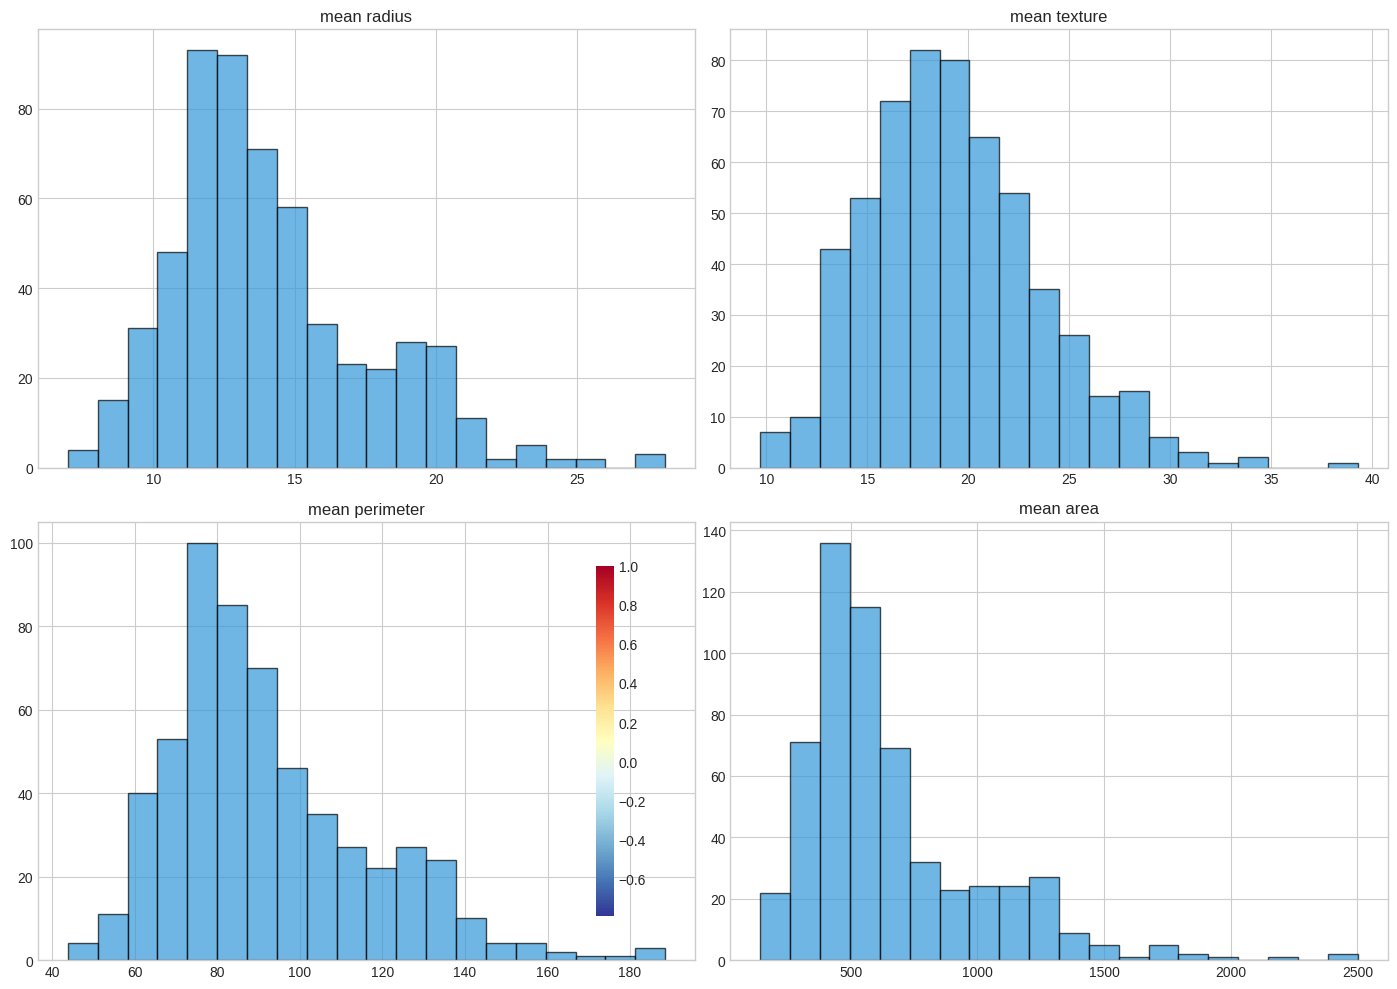


 Key Insights:
• Most correlated feature: worst concave points (0.794)
• Least correlated feature: symmetry error (0.007)
• Class balance: [0.62741652 0.37258348]


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


ax1 = axes[0, 0]
colors = ['#e74c3c', '#2ecc71']
df['target'].value_counts().plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Target Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class (0=Malignant, 1=Benign)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['Malignant', 'Benign'], rotation=0)


ax2 = axes[0, 1]
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
df[top_features].hist(ax=ax2, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
ax2.set_title('Top Features Distribution')


ax3 = axes[1, 0]
correlation = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
top_corr_features = correlation.head(10).index.tolist()
corr_matrix = df[top_corr_features + ['target']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', ax=ax3, fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax3.set_title('Correlation Heatmap (Top 10 Features)', fontsize=12, fontweight='bold')


ax4 = axes[1, 1]
correlation.head(15).plot(kind='barh', ax=ax4, color='#9b59b6')
ax4.set_title('Feature Correlation with Target', fontsize=12, fontweight='bold')
ax4.set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Key Insights:")
print(f"• Most correlated feature: {correlation.idxmax()} ({correlation.max():.3f})")
print(f"• Least correlated feature: {correlation.idxmin()} ({correlation.min():.3f})")
print(f"• Class balance: {df['target'].value_counts(normalize=True).values}")


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


baseline_knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')
baseline_knn.fit(X_train_scaled, y_train)
y_pred_baseline = baseline_knn.predict(X_test_scaled)


baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_cm = confusion_matrix(y_test, y_pred_baseline)

print("=" * 50)
print("BASELINE KNN (K=5, Uniform Weights)")
print("=" * 50)
print(f"\n Accuracy: {baseline_accuracy:.4f}")
print(f"\n Confusion Matrix:\n{baseline_cm}")
print(f"\n Classification Report:\n{classification_report(y_test, y_pred_baseline, target_names=['Malignant', 'Benign'])}")


BASELINE KNN (K=5, Uniform Weights)

 Accuracy: 0.9561

 Confusion Matrix:
[[39  3]
 [ 2 70]]

 Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [5]:
class DistanceWeightedKNN:
    """
    KNN with inverse distance weighting.
    Weight formula: w_i = 1 / (d(x, x_i) + epsilon)
    """

    def __init__(self, k=5, epsilon=1e-5):
        self.k = k
        self.epsilon = epsilon
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _predict_single(self, x):

        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]


        k_indices = np.argsort(distances)[:self.k]
        k_distances = np.array(distances)[k_indices]
        k_labels = self.y_train[k_indices]


        weights = 1 / (k_distances + self.epsilon)


        classes = np.unique(self.y_train)
        weighted_votes = {}
        for c in classes:
            mask = k_labels == c
            weighted_votes[c] = np.sum(weights[mask])

        return max(weighted_votes, key=weighted_votes.get)

    def predict(self, X):
        return np.array([self._predict_single(x) for x in np.array(X)])

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)



dw_knn = DistanceWeightedKNN(k=5, epsilon=1e-5)
dw_knn.fit(X_train_scaled, y_train)
y_pred_weighted = dw_knn.predict(X_test_scaled)

weighted_accuracy = accuracy_score(y_test, y_pred_weighted)
weighted_cm = confusion_matrix(y_test, y_pred_weighted)

print("=" * 50)
print("DISTANCE WEIGHTED KNN (K=5)")
print("=" * 50)
print(f"\n Accuracy: {weighted_accuracy:.4f}")
print(f"\n  Improvement over baseline: {(weighted_accuracy - baseline_accuracy) * 100:.2f}%")
print(f"\n Confusion Matrix:\n{weighted_cm}")
print(f"\n Classification Report:\n{classification_report(y_test, y_pred_weighted, target_names=['Malignant', 'Benign'])}")


DISTANCE WEIGHTED KNN (K=5)

 Accuracy: 0.9561

  Improvement over baseline: 0.00%

 Confusion Matrix:
[[39  3]
 [ 2 70]]

 Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



ADAPTIVE K SELECTION

 Step 1 - Initial K (√N): 21

 Step 2 - Cross-Validation Optimization:
 Cross-Validation K Optimization:
----------------------------------------
K=  3 | CV Accuracy: 0.9692 ± 0.0245
K=  5 | CV Accuracy: 0.9670 ± 0.0209
K=  7 | CV Accuracy: 0.9692 ± 0.0213
K=  9 | CV Accuracy: 0.9692 ± 0.0162
K= 11 | CV Accuracy: 0.9626 ± 0.0149
K= 13 | CV Accuracy: 0.9626 ± 0.0215
K= 15 | CV Accuracy: 0.9648 ± 0.0189
K= 17 | CV Accuracy: 0.9604 ± 0.0247
K= 19 | CV Accuracy: 0.9582 ± 0.0245
K= 21 | CV Accuracy: 0.9626 ± 0.0215
K= 23 | CV Accuracy: 0.9626 ± 0.0215
K= 25 | CV Accuracy: 0.9604 ± 0.0215
K= 27 | CV Accuracy: 0.9582 ± 0.0224
K= 29 | CV Accuracy: 0.9560 ± 0.0231

 Optimal K from CV: 3 (Accuracy: 0.9692)


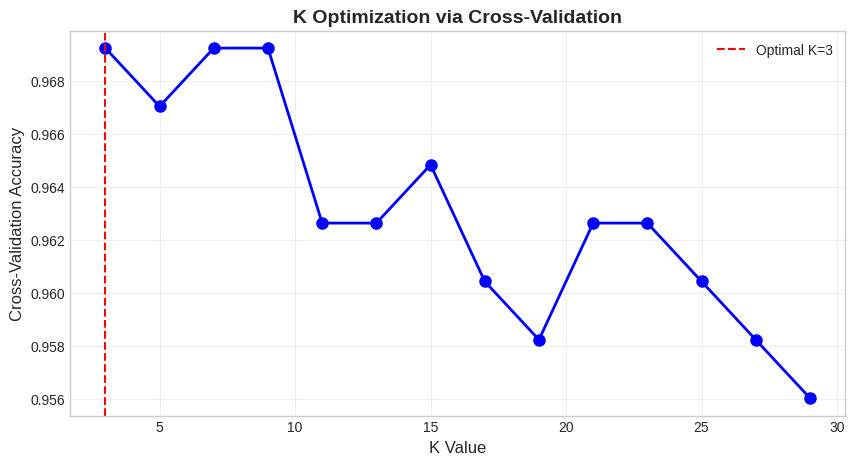

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import NearestNeighbors

class AdaptiveKSelector:
    """
    Adaptive K selection based on:
    1. Initial K = sqrt(N)
    2. Cross-validation optimization
    3. Local density adaptation
    """

    def __init__(self, k_range=None):
        self.k_range = k_range
        self.optimal_k = None
        self.cv_scores = {}

    def find_initial_k(self, X):
        """Step 1: Initial K using sqrt(N)"""
        n_samples = X.shape[0]
        initial_k = int(np.sqrt(n_samples))

        if initial_k % 2 == 0:
            initial_k += 1
        return initial_k

    def optimize_k_cv(self, X, y, k_range=None):
        """Step 2: Optimize K using cross-validation"""
        if k_range is None:
            initial_k = self.find_initial_k(X)
            k_range = range(max(1, initial_k - 10), initial_k + 11, 2)

        best_k = 1
        best_score = 0

        print(" Cross-Validation K Optimization:")
        print("-" * 40)

        for k in k_range:
            if k >= len(X):
                continue
            knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
            scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
            mean_score = scores.mean()
            self.cv_scores[k] = mean_score

            if mean_score > best_score:
                best_score = mean_score
                best_k = k

            print(f"K={k:3d} | CV Accuracy: {mean_score:.4f} ± {scores.std():.4f}")

        self.optimal_k = best_k
        print(f"\n Optimal K from CV: {best_k} (Accuracy: {best_score:.4f})")
        return best_k

    def calculate_local_density(self, X, point, k_density=10):
        """Step 3: Calculate local density for adaptive K"""
        nn = NearestNeighbors(n_neighbors=min(k_density + 1, len(X)))
        nn.fit(X)
        distances, _ = nn.kneighbors([point])

        avg_distance = np.mean(distances[0][1:])
        return 1 / (avg_distance + 1e-5)

    def get_adaptive_k(self, X_train, point, base_k, k_density=10,
                       min_k=3, max_k=50, scale_factor=0.5):
        """
        Adaptive K based on local density:
        - Dense region → smaller K
        - Sparse region → larger K
        """

        local_density = self.calculate_local_density(X_train, point, k_density)


        sample_indices = np.random.choice(len(X_train), min(100, len(X_train)), replace=False)
        densities = [self.calculate_local_density(X_train, X_train[i], k_density)
                     for i in sample_indices]
        avg_density = np.mean(densities)


        density_ratio = local_density / avg_density

        if density_ratio > 1:
            adaptive_k = int(base_k * (1 - scale_factor * (density_ratio - 1)))
        else:
            adaptive_k = int(base_k * (1 + scale_factor * (1 - density_ratio)))


        adaptive_k = max(min_k, min(max_k, adaptive_k))


        if adaptive_k % 2 == 0:
            adaptive_k += 1

        return adaptive_k



selector = AdaptiveKSelector()

print("=" * 50)
print("ADAPTIVE K SELECTION")
print("=" * 50)


initial_k = selector.find_initial_k(X_train_scaled)
print(f"\n Step 1 - Initial K (√N): {initial_k}")


print(f"\n Step 2 - Cross-Validation Optimization:")
optimal_k = selector.optimize_k_cv(X_train_scaled, y_train,
                                    k_range=range(3, 31, 2))


plt.figure(figsize=(10, 5))
ks = list(selector.cv_scores.keys())
scores = list(selector.cv_scores.values())
plt.plot(ks, scores, 'b-o', linewidth=2, markersize=8)
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal K={optimal_k}')
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('K Optimization via Cross-Validation', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('k_optimization.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
class AdaptiveDistanceWeightedKNN:
    """
    Complete Adaptive Distance Weighted KNN:
    - Adaptive K based on local density
    - Inverse distance weighting
    - Optimized hyperparameters
    """

    def __init__(self, base_k=5, epsilon=1e-5, k_density=10,
                 min_k=3, max_k=50, scale_factor=0.3, use_adaptive=True):
        self.base_k = base_k
        self.epsilon = epsilon
        self.k_density = k_density
        self.min_k = min_k
        self.max_k = max_k
        self.scale_factor = scale_factor
        self.use_adaptive = use_adaptive
        self.X_train = None
        self.y_train = None
        self.nn_model = None
        self.densities_cache = None
        self.avg_density = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)


        self.nn_model = NearestNeighbors(n_neighbors=self.max_k)
        self.nn_model.fit(self.X_train)


        if self.use_adaptive:
            sample_size = min(100, len(self.X_train))
            sample_indices = np.random.choice(len(self.X_train), sample_size, replace=False)
            densities = []
            for idx in sample_indices:
                distances, _ = self.nn_model.kneighbors([self.X_train[idx]],
                                                         n_neighbors=self.k_density + 1)
                avg_dist = np.mean(distances[0][1:])
                densities.append(1 / (avg_dist + self.epsilon))
            self.avg_density = np.mean(densities)

        return self

    def _get_local_density(self, point):
        distances, _ = self.nn_model.kneighbors([point], n_neighbors=self.k_density + 1)
        avg_dist = np.mean(distances[0][:self.k_density])
        return 1 / (avg_dist + self.epsilon)

    def _get_adaptive_k(self, point):
        if not self.use_adaptive:
            return self.base_k

        local_density = self._get_local_density(point)
        density_ratio = local_density / self.avg_density

        if density_ratio > 1:
            adaptive_k = int(self.base_k / (1 + self.scale_factor * (density_ratio - 1)))
        else:
            adaptive_k = int(self.base_k * (1 + self.scale_factor * (1 - density_ratio)))

        adaptive_k = max(self.min_k, min(self.max_k, adaptive_k))
        if adaptive_k % 2 == 0:
            adaptive_k += 1
        return adaptive_k

    def _predict_single(self, x):

        k = self._get_adaptive_k(x)


        distances, indices = self.nn_model.kneighbors([x], n_neighbors=k)
        distances = distances[0]
        indices = indices[0]


        k_labels = self.y_train[indices]


        weights = 1 / (distances + self.epsilon)


        classes = np.unique(self.y_train)
        weighted_votes = {}
        for c in classes:
            mask = k_labels == c
            weighted_votes[c] = np.sum(weights[mask])

        return max(weighted_votes, key=weighted_votes.get)

    def predict(self, X):
        return np.array([self._predict_single(x) for x in np.array(X)])

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def get_params(self):
        return {
            'base_k': self.base_k,
            'epsilon': self.epsilon,
            'k_density': self.k_density,
            'min_k': self.min_k,
            'max_k': self.max_k,
            'scale_factor': self.scale_factor,
            'use_adaptive': self.use_adaptive
        }



print("=" * 50)
print("FINAL MODEL: ADAPTIVE DISTANCE WEIGHTED KNN")
print("=" * 50)

adaptive_knn = AdaptiveDistanceWeightedKNN(
    base_k=optimal_k,
    epsilon=1e-5,
    k_density=10,
    min_k=3,
    max_k=31,
    scale_factor=0.3,
    use_adaptive=True
)

adaptive_knn.fit(X_train_scaled, y_train)
y_pred_adaptive = adaptive_knn.predict(X_test_scaled)

adaptive_accuracy = accuracy_score(y_test, y_pred_adaptive)
adaptive_cm = confusion_matrix(y_test, y_pred_adaptive)

print(f"\n Accuracy: {adaptive_accuracy:.4f}")
print(f" Improvement over baseline: {(adaptive_accuracy - baseline_accuracy) * 100:.2f}%")
print(f" Improvement over weighted: {(adaptive_accuracy - weighted_accuracy) * 100:.2f}%")
print(f"\n Confusion Matrix:\n{adaptive_cm}")
print(f"\n Classification Report:\n{classification_report(y_test, y_pred_adaptive, target_names=['Malignant', 'Benign'])}")


FINAL MODEL: ADAPTIVE DISTANCE WEIGHTED KNN

 Accuracy: 0.9825
 Improvement over baseline: 2.63%
 Improvement over weighted: 2.63%

 Confusion Matrix:
[[40  2]
 [ 0 72]]

 Classification Report:
              precision    recall  f1-score   support

   Malignant       1.00      0.95      0.98        42
      Benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

def comprehensive_evaluation(y_true, y_pred, model_name):
    """Generate comprehensive evaluation metrics"""
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'Specificity': recall_score(y_true, y_pred, pos_label=0)
    }
    return metrics


baseline_metrics = comprehensive_evaluation(y_test, y_pred_baseline, 'Baseline KNN')
weighted_metrics = comprehensive_evaluation(y_test, y_pred_weighted, 'Distance Weighted KNN')
adaptive_metrics = comprehensive_evaluation(y_test, y_pred_adaptive, 'Adaptive DW-KNN')


results_df = pd.DataFrame([baseline_metrics, weighted_metrics, adaptive_metrics])
results_df = results_df.set_index('Model')

print("=" * 60)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)
print("\n Performance Metrics Comparison:\n")
print(results_df.round(4).to_string())


COMPREHENSIVE MODEL EVALUATION

 Performance Metrics Comparison:

                       Accuracy  Precision  Recall  F1-Score  Specificity
Model                                                                    
Baseline KNN             0.9561     0.9589  0.9722    0.9655       0.9286
Distance Weighted KNN    0.9561     0.9589  0.9722    0.9655       0.9286
Adaptive DW-KNN          0.9825     0.9730  1.0000    0.9863       0.9524


In [9]:

print("\n" + "=" * 70)
print("MODEL COMPARISON ANALYSIS")
print("=" * 70)

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity'],
    'Baseline KNN': [baseline_accuracy,
                     precision_score(y_test, y_pred_baseline),
                     recall_score(y_test, y_pred_baseline),
                     f1_score(y_test, y_pred_baseline),
                     recall_score(y_test, y_pred_baseline, pos_label=0)],
    'Weighted KNN': [weighted_accuracy,
                     precision_score(y_test, y_pred_weighted),
                     recall_score(y_test, y_pred_weighted),
                     f1_score(y_test, y_pred_weighted),
                     recall_score(y_test, y_pred_weighted, pos_label=0)],
    'Adaptive DW-KNN': [adaptive_accuracy,
                        precision_score(y_test, y_pred_adaptive),
                        recall_score(y_test, y_pred_adaptive),
                        f1_score(y_test, y_pred_adaptive),
                        recall_score(y_test, y_pred_adaptive, pos_label=0)]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.set_index('Metric')


comparison_df['Improvement (%)'] = ((comparison_df['Adaptive DW-KNN'] - comparison_df['Baseline KNN']) / comparison_df['Baseline KNN'] * 100).round(2)

print("\n Performance Comparison Table:\n")
print(comparison_df.round(4).to_string())


print("\n\n Key Findings:")
print("-" * 50)
print(f"• Baseline KNN Accuracy: {baseline_accuracy:.4f}")
print(f"• Distance Weighted KNN Accuracy: {weighted_accuracy:.4f}")
print(f"• Adaptive DW-KNN Accuracy: {adaptive_accuracy:.4f}")
print(f"\n• Total Improvement: {(adaptive_accuracy - baseline_accuracy) * 100:.2f}%")
print(f"• Best Performing Model: Adaptive Distance Weighted KNN")



MODEL COMPARISON ANALYSIS

 Performance Comparison Table:

             Baseline KNN  Weighted KNN  Adaptive DW-KNN  Improvement (%)
Metric                                                                   
Accuracy           0.9561        0.9561           0.9825             2.75
Precision          0.9589        0.9589           0.9730             1.47
Recall             0.9722        0.9722           1.0000             2.86
F1-Score           0.9655        0.9655           0.9863             2.15
Specificity        0.9286        0.9286           0.9524             2.56


 Key Findings:
--------------------------------------------------
• Baseline KNN Accuracy: 0.9561
• Distance Weighted KNN Accuracy: 0.9561
• Adaptive DW-KNN Accuracy: 0.9825

• Total Improvement: 2.63%
• Best Performing Model: Adaptive Distance Weighted KNN


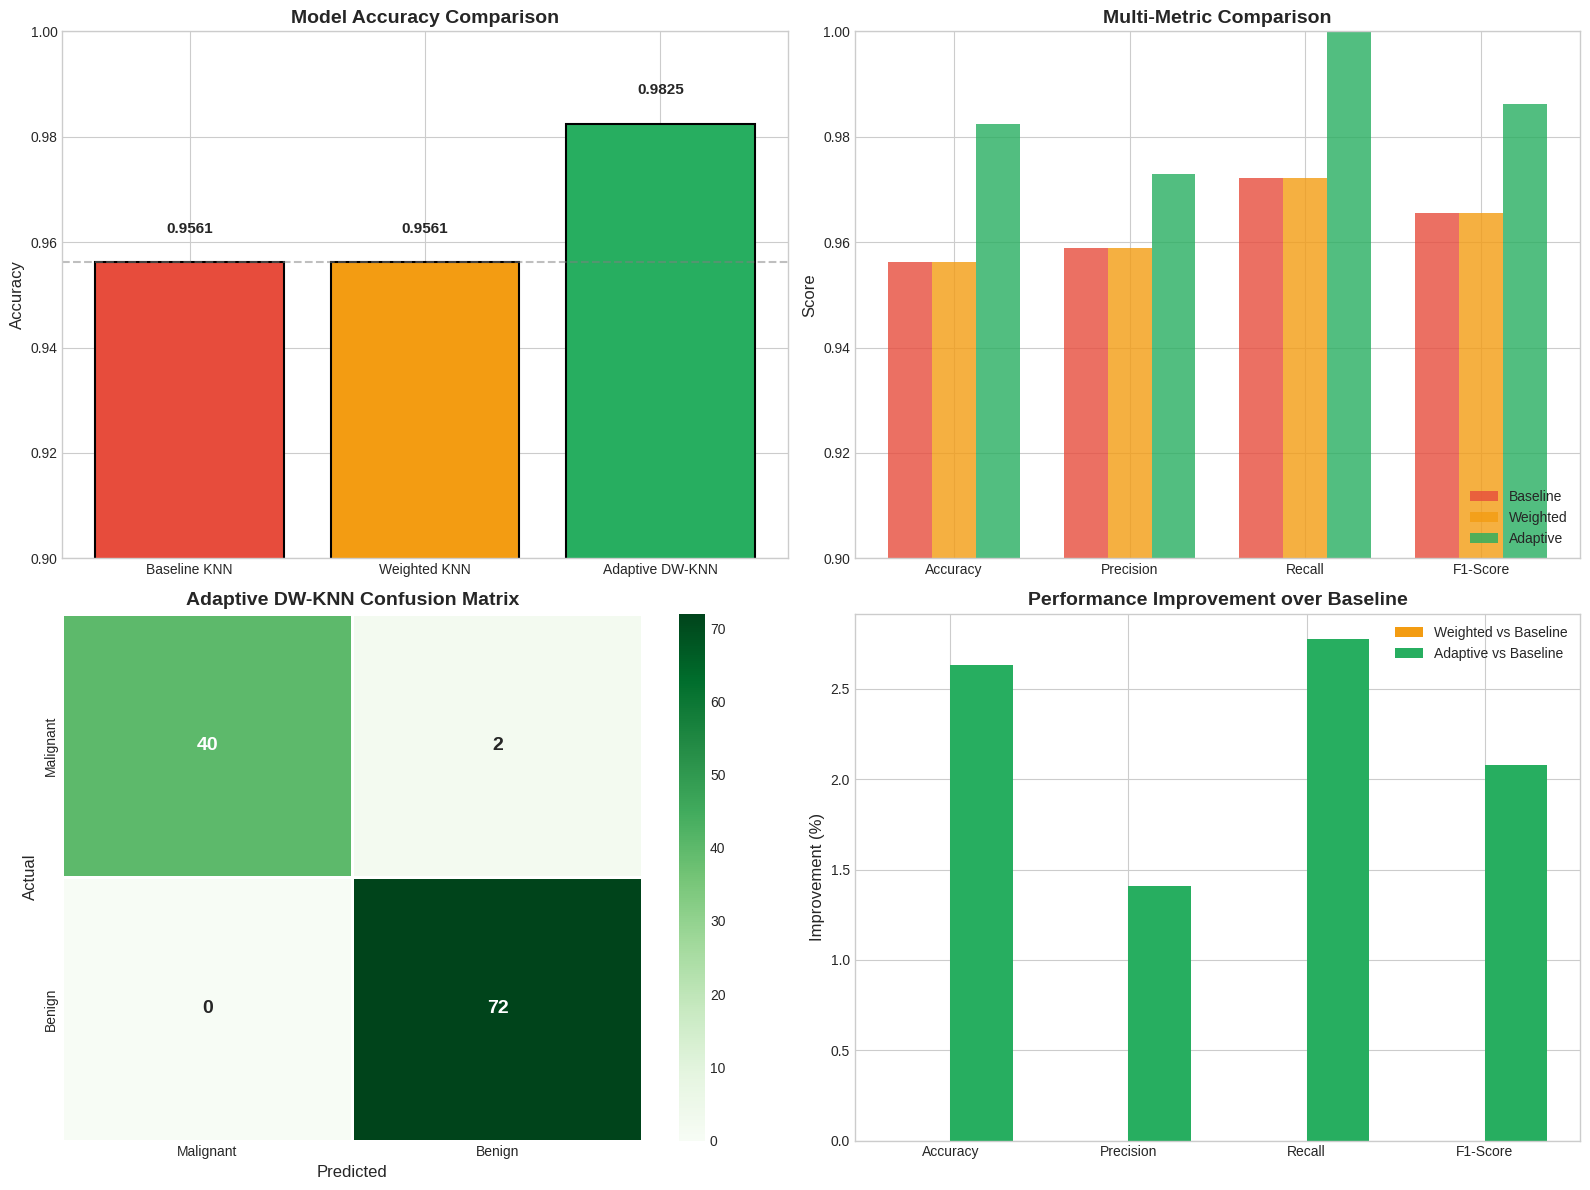

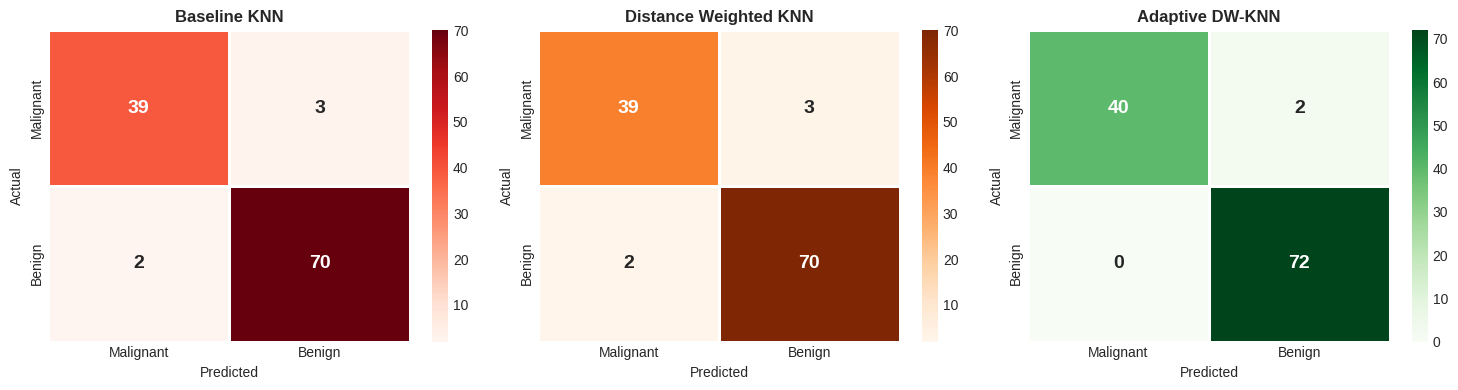

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(16, 12))


ax1 = fig.add_subplot(2, 2, 1)
models = ['Baseline KNN', 'Weighted KNN', 'Adaptive DW-KNN']
accuracies = [baseline_accuracy, weighted_accuracy, adaptive_accuracy]
colors = ['#e74c3c', '#f39c12', '#27ae60']
bars = ax1.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylim(0.9, 1.0)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.axhline(y=baseline_accuracy, color='gray', linestyle='--', alpha=0.5)


ax2 = fig.add_subplot(2, 2, 2)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

baseline_vals = [baseline_accuracy, precision_score(y_test, y_pred_baseline),
                 recall_score(y_test, y_pred_baseline), f1_score(y_test, y_pred_baseline)]
weighted_vals = [weighted_accuracy, precision_score(y_test, y_pred_weighted),
                 recall_score(y_test, y_pred_weighted), f1_score(y_test, y_pred_weighted)]
adaptive_vals = [adaptive_accuracy, precision_score(y_test, y_pred_adaptive),
                 recall_score(y_test, y_pred_adaptive), f1_score(y_test, y_pred_adaptive)]

ax2.bar(x - width, baseline_vals, width, label='Baseline', color='#e74c3c', alpha=0.8)
ax2.bar(x, weighted_vals, width, label='Weighted', color='#f39c12', alpha=0.8)
ax2.bar(x + width, adaptive_vals, width, label='Adaptive', color='#27ae60', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0.9, 1.0)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Multi-Metric Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')


ax3 = fig.add_subplot(2, 2, 3)
cm_adaptive = confusion_matrix(y_test, y_pred_adaptive)
sns.heatmap(cm_adaptive, annot=True, fmt='d', cmap='Greens', ax=ax3,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'],
            annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2)
ax3.set_title('Adaptive DW-KNN Confusion Matrix', fontsize=14, fontweight='bold')
ax3.set_xlabel('Predicted', fontsize=12)
ax3.set_ylabel('Actual', fontsize=12)


ax4 = fig.add_subplot(2, 2, 4)
improvement_baseline = [(w - b) * 100 for w, b in zip(weighted_vals, baseline_vals)]
improvement_adaptive = [(a - b) * 100 for a, b in zip(adaptive_vals, baseline_vals)]
x = np.arange(len(metrics))
width = 0.35
ax4.bar(x - width/2, improvement_baseline, width, label='Weighted vs Baseline', color='#f39c12')
ax4.bar(x + width/2, improvement_adaptive, width, label='Adaptive vs Baseline', color='#27ae60')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_ylabel('Improvement (%)', fontsize=12)
ax4.set_title('Performance Improvement over Baseline', fontsize=14, fontweight='bold')
ax4.legend()
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


fig2, axes = plt.subplots(1, 3, figsize=(15, 4))
cms = [confusion_matrix(y_test, y_pred_baseline),
       confusion_matrix(y_test, y_pred_weighted),
       confusion_matrix(y_test, y_pred_adaptive)]
titles = ['Baseline KNN', 'Distance Weighted KNN', 'Adaptive DW-KNN']
cmaps = ['Reds', 'Oranges', 'Greens']

for ax, cm, title, cmap in zip(axes, cms, titles, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'],
                annot_kws={'size': 14, 'weight': 'bold'}, linewidths=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
